In [1]:
import os
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from utils8 import AudioCNN
from utils8.data import AudioDataset, get_dataloader

# Get Data
path = os.path.join('Data', 'Digits')
classes = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
dataset = AudioDataset(path, classes)

# Data Split and Subsets
idx = list(range(len(dataset)))
labels = dataset.labels
train_val_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)

train_val_set = Subset(dataset, train_val_idx)
test_set = Subset(dataset, test_idx)

# Training

In [8]:
import os
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch import nn,optim
from utils8.dir_managment import clean_dir
from utils8.AudioCNN import AudioCNN
from utils8.training import train_one_fold, get_train_loaders, save_model_dict, save_target_labels


model_name = 'model_1'

log_dir = os.path.join('runs', 'training', model_name)
clean_dir(log_dir)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

save_model_dir = os.path.join('Models', model_name)
clean_dir(save_model_dir)
os.makedirs(save_model_dir, exist_ok=True)

model_params = {'dropout_rate': 0.3, 'num_classes': 10}
save_model_dict(model_params, save_model_dir)
save_target_labels(classes, save_model_dir)

N_EPOCHS = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_set)):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')
    # Loaders
    train_loader, val_loader = get_train_loaders(train_val_set, train_idx,val_idx , batch_size=32)

    # Model, Optimizer, Criterion
    criterion = nn.CrossEntropyLoss()
    model = AudioCNN()
    optimizer = optim.Adam(model.parameters(), lr=0.2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

    # Fold Training
    loss = train_one_fold(fold, model, train_loader, val_loader, optimizer, scheduler, criterion, n_epochs=N_EPOCHS, write_model_dir=save_model_dir, writer=writer)




Cleaning existing files at runs/training/model_1...

 ===================== Training Fold 0  ===================== 

Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.350275573907075
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3363315176080772
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3149231429453248
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3071690135531955
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3049488641597606
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.303742556660264
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3036635760907775
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.303495504237987
Saved new best model to Models/model_1/fold_0.pth, with new best_val_loss=2.3033474440927857
Saved new best model to Models/model_1/fold_0.pth

In [ ]:
# tensorboard --logdir Lab8/runs/training/model_1

# Model Evaluation

In [2]:
import os
from utils8.Predictor import Predictor

model_path = os.path.join('Models', 'model_1')
predictor_obj = Predictor(model_path)

In [3]:
model = predictor_obj.folds[0]

model

AudioCNN(
  (features): Sequential(
    (0): Conv1d(1, 8, kernel_size=(13,), stride=(1,), padding=valid)
    (1): ReLU()
    (2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(8, 16, kernel_size=(11,), stride=(1,), padding=valid)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
    (8): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=valid)
    (9): ReLU()
    (10): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.3, inplace=False)
    (12): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=valid)
    (13): ReLU()
    (14): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6080, out_features=25

In [9]:


loader = get_dataloader(dataset, batch_size=100)
x,y  =  next(iter(loader))

y

tensor([5, 3, 7, 9, 7, 4, 3, 1, 5, 0, 3, 8, 2, 6, 0, 4, 4, 7, 4, 7, 3, 2, 8, 5,
        8, 0, 8, 7, 4, 4, 8, 6, 0, 1, 2, 8, 6, 3, 5, 3, 1, 9, 1, 8, 7, 8, 7, 0,
        7, 8, 7, 6, 0, 2, 3, 3, 7, 4, 9, 3, 2, 9, 6, 4, 7, 0, 5, 1, 3, 2, 3, 2,
        2, 2, 1, 0, 6, 1, 5, 7, 9, 5, 8, 3, 4, 0, 4, 1, 0, 1, 9, 8, 2, 8, 6, 2,
        3, 6, 1, 3])

In [33]:
from utils8.AudioCNN import AudioCNN
import torch

model1 = AudioCNN()

state_d = torch.load('Models/model_1/fold_1.pth', weights_only=True)
model1.load_state_dict(state_d)
model1(x).argmax(axis=1)

tensor([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6])

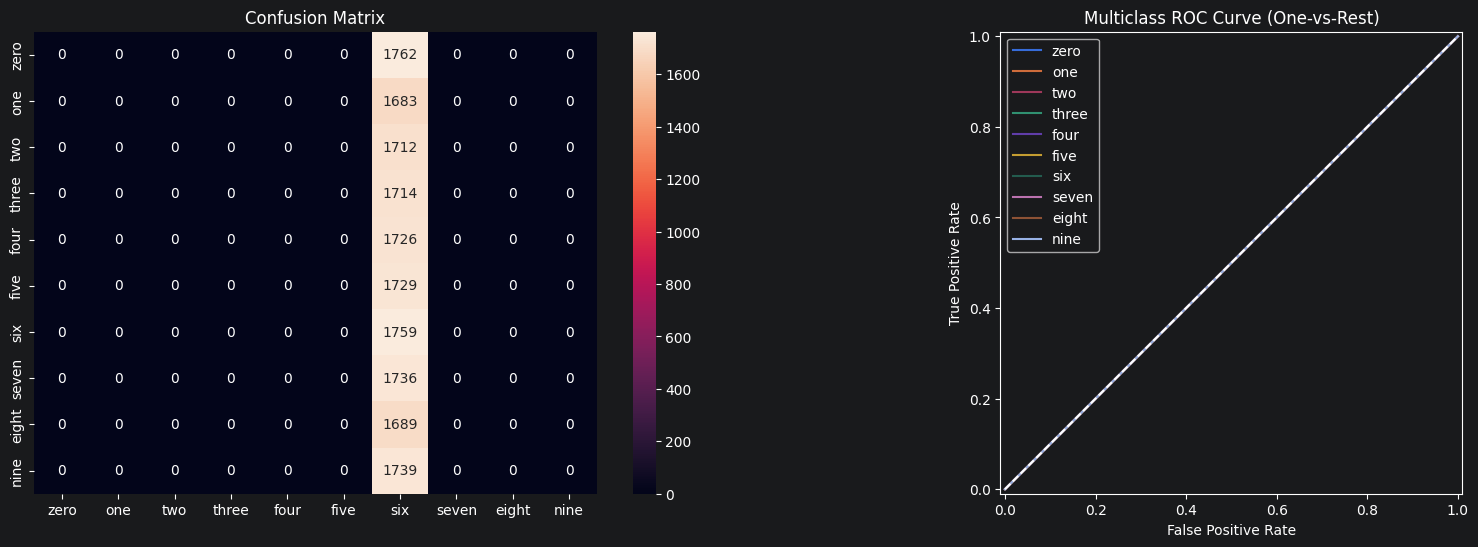

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1762
           1       0.00      0.00      0.00      1683
           2       0.00      0.00      0.00      1712
           3       0.00      0.00      0.00      1714
           4       0.00      0.00      0.00      1726
           5       0.00      0.00      0.00      1729
           6       0.10      1.00      0.19      1759
           7       0.00      0.00      0.00      1736
           8       0.00      0.00      0.00      1689
           9       0.00      0.00      0.00      1739

    accuracy                           0.10     17249
   macro avg       0.01      0.10      0.02     17249
weighted avg       0.01      0.10      0.02     17249



In [34]:
# Train data Classification report
predictor_obj.metric_report(data=Subset(dataset, train_val_idx))


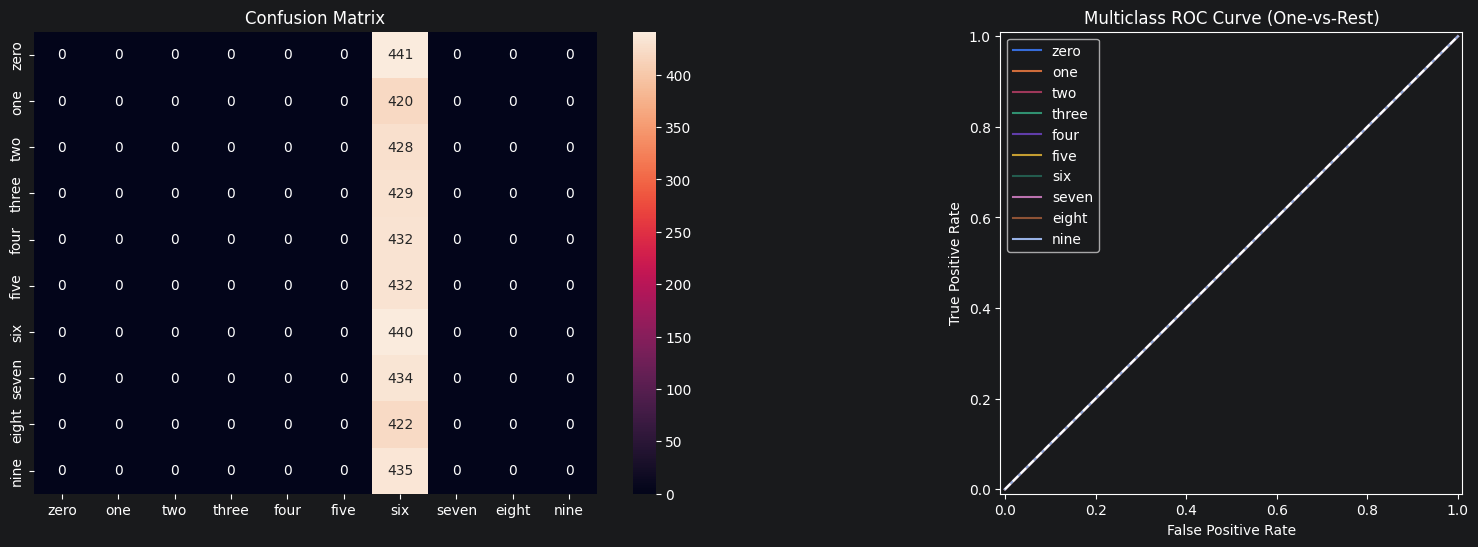

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       441
           1       0.00      0.00      0.00       420
           2       0.00      0.00      0.00       428
           3       0.00      0.00      0.00       429
           4       0.00      0.00      0.00       432
           5       0.00      0.00      0.00       432
           6       0.10      1.00      0.19       440
           7       0.00      0.00      0.00       434
           8       0.00      0.00      0.00       422
           9       0.00      0.00      0.00       435

    accuracy                           0.10      4313
   macro avg       0.01      0.10      0.02      4313
weighted avg       0.01      0.10      0.02      4313



In [3]:
# Test data Classification report
predictor_obj.metric_report(data=Subset(dataset, test_idx))